# U-Net vs U-Net++ Road Segmentation

## 프로젝트 목표

1. 학습 노드의 U-Net 구조를 재현한다.
2. U-Net의 encoder-decoder 구조와 skip connection을 이해한다.
3. U-Net++의 nested dense skip connection을 직접 구현한다.
4. 두 모델을 동일한 데이터·손실함수·학습조건에서 비교한다.
5. IoU와 결과 mask 시각화를 이용해 정량적·정성적으로 성능을 비교한다.


## ⭐️비교 원칙☝️

U-Net과 U-Net++의 구조 외에는 가능한 한 동일하게 유지한다.

**루브릭 3번 비교실험의 근거가 됨!**

- 동일 데이터 split
- 동일 augmentation
- 동일 input size
- 동일 optimizer
- 동일 learning rate
- 동일 loss
- 동일 epoch
- 동일 evaluation metric

### (비밀) 실험 결과 스포일러(내용이 길어서 지루할까봐요)



> U-Net++는 U-Net보다 도로를 덜 놓치는 대신 약간 더 과하게 칠하는 경향을 보였고, 그 trade-off 결과 전체 overlap 성능은 소폭 좋아졌다.



In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
from pathlib import Path

ROOT = Path(
    "/content/drive/MyDrive/Colab Notebooks/2026.789_AI researcher"
)

DATA_DIR = ROOT / "data" / "segmentation"
MODEL_DIR = ROOT / "models" / "segmentation"
OUTPUT_DIR = ROOT / "outputs" / "segmentation"
EXAMPLE_DIR = ROOT / "이전 예제"

FIGURE_DIR = OUTPUT_DIR / "figures"
PRED_DIR = OUTPUT_DIR / "predictions"
METRIC_DIR = OUTPUT_DIR / "metrics"
LOG_DIR = OUTPUT_DIR / "logs"

for path in [
    DATA_DIR,
    MODEL_DIR,
    OUTPUT_DIR,
    FIGURE_DIR,
    PRED_DIR,
    METRIC_DIR,
    LOG_DIR,
]:
    path.mkdir(parents=True, exist_ok=True)

print("ROOT       :", ROOT)
print("DATA_DIR   :", DATA_DIR)
print("MODEL_DIR  :", MODEL_DIR)
print("OUTPUT_DIR :", OUTPUT_DIR)

ROOT       : /content/drive/MyDrive/Colab Notebooks/2026.789_AI researcher
DATA_DIR   : /content/drive/MyDrive/Colab Notebooks/2026.789_AI researcher/data/segmentation
MODEL_DIR  : /content/drive/MyDrive/Colab Notebooks/2026.789_AI researcher/models/segmentation
OUTPUT_DIR : /content/drive/MyDrive/Colab Notebooks/2026.789_AI researcher/outputs/segmentation


In [14]:
from pathlib import Path

# Colab 세션용 임시 데이터 루트
LOCAL_DATA_ROOT = Path("/content/kitti_segmentation")
LOCAL_DATA_DIR = LOCAL_DATA_ROOT / "data"
ZIP_PATH = LOCAL_DATA_ROOT / "data_semantics.zip"

LOCAL_DATA_ROOT.mkdir(parents=True, exist_ok=True)

print("LOCAL_DATA_ROOT:", LOCAL_DATA_ROOT)
print("LOCAL_DATA_DIR :", LOCAL_DATA_DIR)
print("ZIP_PATH       :", ZIP_PATH)

LOCAL_DATA_ROOT: /content/kitti_segmentation
LOCAL_DATA_DIR : /content/kitti_segmentation/data
ZIP_PATH       : /content/kitti_segmentation/data_semantics.zip


In [3]:
# 현재 환경 체크
import sys
import torch
import numpy as np
import PIL
import skimage

print("Python :", sys.version)
print("PyTorch:", torch.__version__)
print("NumPy  :", np.__version__)
print("Pillow :", PIL.__version__)
print("skimage:", skimage.__version__)

print("\nCUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print(
        "VRAM:",
        round(torch.cuda.get_device_properties(0).total_memory / 1024**3, 2),
        "GB"
    )

Python : 3.13.15 (main, Aug  6 2026, 11:06:23) [GCC 11.4.0]
PyTorch: 2.11.0+cu128
NumPy  : 2.1.3
Pillow : 11.3.0
skimage: 0.25.2

CUDA available: True
GPU: NVIDIA L4
VRAM: 22.03 GB


In [4]:
try:
    import albumentations as A
    print("Albumentations:", A.__version__)
except ImportError:
    print("Albumentations is not installed.")

Albumentations: 2.0.8


In [15]:
import subprocess

KITTI_URL = (
    "https://s3.eu-central-1.amazonaws.com/"
    "avg-kitti/data_semantics.zip"
)

if not ZIP_PATH.exists():
    print("KITTI semantic dataset 다운로드 시작")

    subprocess.run(
        [
            "wget",
            "-O",
            str(ZIP_PATH),
            KITTI_URL,
        ],
        check=True,
    )

    print("다운로드 완료:", ZIP_PATH)

else:
    print("이미 zip 파일이 존재합니다:", ZIP_PATH)

KITTI semantic dataset 다운로드 시작
다운로드 완료: /content/kitti_segmentation/data_semantics.zip


In [16]:
import zipfile

if not LOCAL_DATA_DIR.exists():
    LOCAL_DATA_DIR.mkdir(
        parents=True,
        exist_ok=True,
    )

# 이미 training 폴더가 있으면 재압축해제하지 않음
training_dir = LOCAL_DATA_DIR / "training"

if not training_dir.exists():

    print("압축 해제 시작")

    with zipfile.ZipFile(
        ZIP_PATH,
        "r",
    ) as zip_ref:

        zip_ref.extractall(
            LOCAL_DATA_DIR
        )

    print("압축 해제 완료")

else:
    print(
        "이미 압축 해제된 데이터가 있습니다:",
        training_dir
    )

압축 해제 시작
압축 해제 완료


In [17]:
print("=== KITTI 데이터 구조 ===")

for p in sorted(
    LOCAL_DATA_DIR.rglob("*")
):
    if p.is_dir():
        print(
            "[DIR]",
            p.relative_to(
                LOCAL_DATA_DIR
            )
        )

=== KITTI 데이터 구조 ===
[DIR] testing
[DIR] testing/image_2
[DIR] training
[DIR] training/image_2
[DIR] training/instance
[DIR] training/semantic
[DIR] training/semantic_rgb


In [18]:
# 이미지와 정답 마스크 경로 지정
IMAGE_DIR = (
    LOCAL_DATA_DIR
    / "training"
    / "image_2"
)

MASK_DIR = (
    LOCAL_DATA_DIR
    / "training"
    / "semantic"
)

print("IMAGE_DIR:", IMAGE_DIR)
print("exists:", IMAGE_DIR.exists())

print()

print("MASK_DIR:", MASK_DIR)
print("exists:", MASK_DIR.exists())

IMAGE_DIR: /content/kitti_segmentation/data/training/image_2
exists: True

MASK_DIR: /content/kitti_segmentation/data/training/semantic
exists: True


In [19]:
# 파일 수 확인
image_paths = sorted(
    IMAGE_DIR.glob("*.png")
)

mask_paths = sorted(
    MASK_DIR.glob("*.png")
)

print(
    "Images:",
    len(image_paths)
)

print(
    "Masks :",
    len(mask_paths)
)

Images: 200
Masks : 200


In [21]:
for i in range(
    min(5, len(image_paths))
):
    print(
        f"[{i}]",
        image_paths[i].name,
        "<->",
        mask_paths[i].name,
    )

[0] 000000_10.png <-> 000000_10.png
[1] 000001_10.png <-> 000001_10.png
[2] 000002_10.png <-> 000002_10.png
[3] 000003_10.png <-> 000003_10.png
[4] 000004_10.png <-> 000004_10.png


In [22]:
# 파일 명 기준으로 페어 생성
mask_by_name = {
    path.name: path
    for path in mask_paths
}

all_pairs = []

missing_masks = []

for image_path in image_paths:

    mask_path = mask_by_name.get(
        image_path.name
    )

    if mask_path is None:
        missing_masks.append(
            image_path.name
        )

    else:
        all_pairs.append(
            (
                image_path,
                mask_path,
            )
        )


print(
    "전체 image 수:",
    len(image_paths)
)

print(
    "정상 pair 수:",
    len(all_pairs)
)

print(
    "mask 누락:",
    len(missing_masks)
)

전체 image 수: 200
정상 pair 수: 200
mask 누락: 0


In [23]:
print("첫 번째 pair")

print(
    "Image:",
    all_pairs[0][0]
)

print(
    "Mask :",
    all_pairs[0][1]
)

첫 번째 pair
Image: /content/kitti_segmentation/data/training/image_2/000000_10.png
Mask : /content/kitti_segmentation/data/training/semantic/000000_10.png


In [5]:
# Seed 고정하기
import random
import os

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("device:", device)

device: cuda


### Loss 설계

프로젝트에서 `BCE + Dice coefficient` 를 제시했기 때문에



> *Loss =
BCEWithLogitsLoss
+
DiceLoss*



예측 도로 영역과 실제 도로 영역이 얼마나 겹치는 가를 보기 위함:

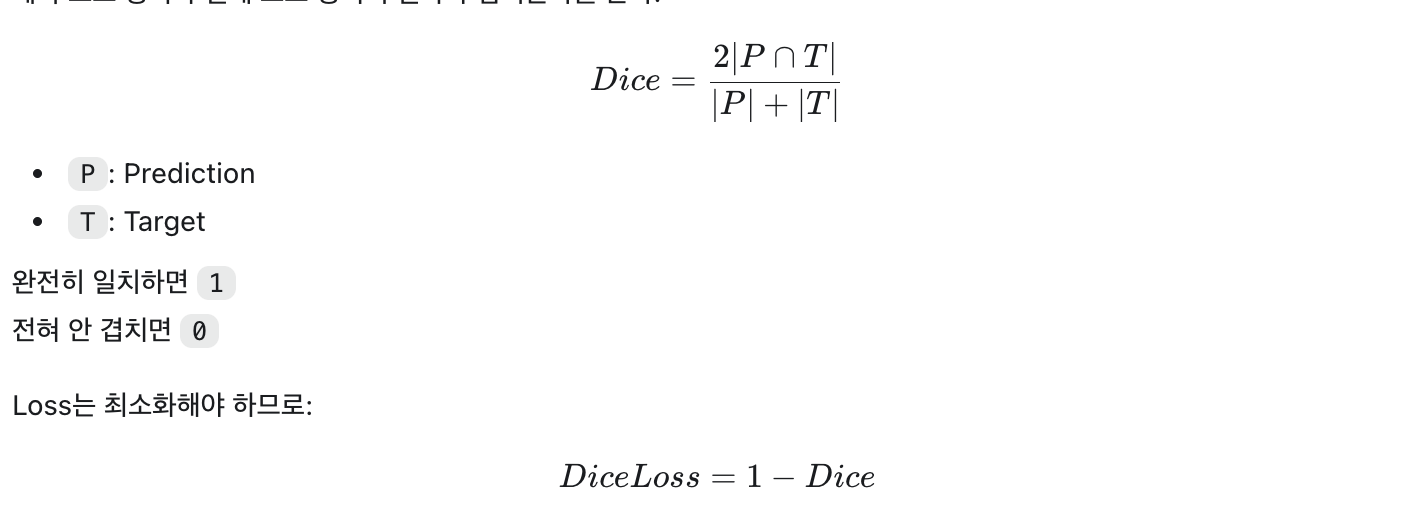

In [6]:
import torch.nn as nn


def dice_coefficient_from_logits(
    logits,
    targets,
    smooth=1e-6,
):
    probs = torch.sigmoid(logits)

    probs = probs.view(probs.size(0), -1)
    targets = targets.view(targets.size(0), -1)

    intersection = (probs * targets).sum(dim=1)

    dice = (
        (2.0 * intersection + smooth)
        / (
            probs.sum(dim=1)
            + targets.sum(dim=1)
            + smooth
        )
    )

    return dice.mean()


class BCEDiceLoss(nn.Module):
    def __init__(self, bce_weight=0.5, dice_weight=0.5):
        super().__init__()
        self.bce = nn.BCEWithLogitsLoss()
        self.bce_weight = bce_weight
        self.dice_weight = dice_weight

    def forward(self, logits, targets):
        bce = self.bce(logits, targets)
        dice = dice_coefficient_from_logits(
            logits,
            targets
        )
        dice_loss = 1.0 - dice

        return (
            self.bce_weight * bce
            + self.dice_weight * dice_loss
        )


criterion = BCEDiceLoss()

🔎*중요*
U-Net 하고 U-Net++ 둘 다 동일한 Loss를 씀.

`IoU`는 Loss와 별개로 Metric이다.

In [7]:
@torch.no_grad()
def binary_iou_from_logits(
    logits,
    targets,
    threshold=0.5,
    smooth=1e-6,
):
    probs = torch.sigmoid(logits)

    preds = (probs >= threshold).float()
    targets = (targets >= 0.5).float()

    preds = preds.view(preds.size(0), -1)
    targets = targets.view(targets.size(0), -1)

    intersection = (preds * targets).sum(dim=1)
    union = (
        preds.sum(dim=1)
        + targets.sum(dim=1)
        - intersection
    )

    iou = (
        intersection + smooth
    ) / (
        union + smooth
    )

    return iou.mean()

### Train/ Val/ Test 고정하기

In [24]:
from sklearn.model_selection import (
    train_test_split
)

train_pairs, temp_pairs = (
    train_test_split(
        all_pairs,
        test_size=0.2,
        random_state=SEED,
        shuffle=True,
    )
)

val_pairs, test_pairs = (
    train_test_split(
        temp_pairs,
        test_size=0.5,
        random_state=SEED,
        shuffle=True,
    )
)

print(
    f"Total : {len(all_pairs)}"
)

print(
    f"Train : {len(train_pairs)}"
)

print(
    f"Val   : {len(val_pairs)}"
)

print(
    f"Test  : {len(test_pairs)}"
)

Total : 200
Train : 160
Val   : 20
Test  : 20


In [25]:
# 비율 체크
total = len(all_pairs)

print(
    "Train ratio:",
    len(train_pairs) / total
)

print(
    "Val ratio:",
    len(val_pairs) / total
)

print(
    "Test ratio:",
    len(test_pairs) / total
)

Train ratio: 0.8
Val ratio: 0.1
Test ratio: 0.1


In [26]:
# 런타임 나가면 다시 세팅하기 번거로우니 스플릿 드라이브 저장
import json

split_info = {
    "seed": SEED,

    "train": [
        image_path.name
        for image_path, _
        in train_pairs
    ],

    "val": [
        image_path.name
        for image_path, _
        in val_pairs
    ],

    "test": [
        image_path.name
        for image_path, _
        in test_pairs
    ],
}

split_path = (
    METRIC_DIR
    / "kitti_split_seed42.json"
)

with open(
    split_path,
    "w",
    encoding="utf-8",
) as f:

    json.dump(
        split_info,
        f,
        ensure_ascii=False,
        indent=2,
    )

print(
    "Split saved:",
    split_path
)

Split saved: /content/drive/MyDrive/Colab Notebooks/2026.789_AI researcher/outputs/segmentation/metrics/kitti_split_seed42.json


### 여기까지 해서 환경 구성은 이렇게 생겼습니다~



```
/content/kitti_segmentation/
        │
        ├─ KITTI 원본 이미지
        └─ KITTI mask
              ↓
        학습할 때만 사용


Google Drive/
2026.789_AI researcher/
        │
        ├─ models/
        │   ├─ unet_best.pth
        │   └─ unetpp_best.pth
        │
        └─ outputs/
            ├─ curves
            ├─ predictions
            ├─ comparison.csv
            └─ kitti_split_seed42.json
```



In [27]:
# KITTI 마스크 원본 값 한번 확인해보기.
import cv2
import numpy as np

sample_image_path, sample_mask_path = all_pairs[0]

sample_image = cv2.imread(str(sample_image_path))
sample_image = cv2.cvtColor(
    sample_image,
    cv2.COLOR_BGR2RGB
)

sample_mask = cv2.imread(
    str(sample_mask_path),
    cv2.IMREAD_GRAYSCALE
)

print("Image shape:", sample_image.shape)
print("Mask shape :", sample_mask.shape)

unique_values, counts = np.unique(
    sample_mask,
    return_counts=True
)

print("\nMask unique values:")
for value, count in zip(
    unique_values,
    counts
):
    print(
        f"class {value:3d}: "
        f"{count:,} pixels"
    )

Image shape: (375, 1242, 3)
Mask shape : (375, 1242)

Mask unique values:
class   4: 723 pixels
class   7: 116,061 pixels
class   8: 7,789 pixels
class  11: 98,002 pixels
class  12: 4,610 pixels
class  13: 17,753 pixels
class  17: 1,636 pixels
class  20: 1,562 pixels
class  21: 116,762 pixels
class  23: 14,847 pixels
class  24: 513 pixels
class  26: 85,390 pixels
class  27: 47 pixels
class  28: 55 pixels


In [28]:
# 길 ... road binary mask 비율도 체크
road_mask = (
    sample_mask == 7
).astype(np.uint8)

print(
    "Road pixels:",
    int(road_mask.sum())
)

print(
    "Road ratio:",
    road_mask.mean()
)

Road pixels: 116061
Road ratio: 0.2491916264090177


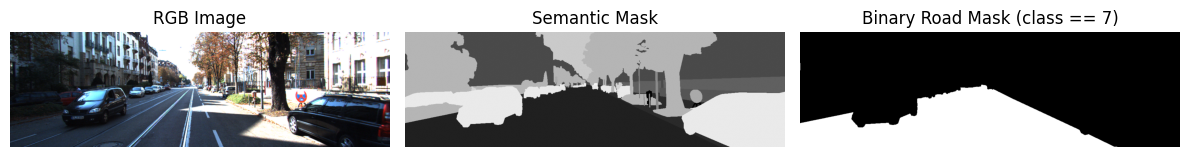

In [29]:
# 내가 직접 눈으로 확인해보기
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(sample_image)
plt.title("RGB Image")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(
    sample_mask,
    cmap="gray"
)
plt.title("Semantic Mask")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(
    road_mask,
    cmap="gray"
)
plt.title("Binary Road Mask (class == 7)")
plt.axis("off")

plt.tight_layout()
plt.show()

#### *호오... 도로 마스크 영역 잘 돼있네요. 저만 잘하면 되겠네요.*

In [30]:
# 데이터셋 클래스 정리하기
from torch.utils.data import Dataset
import torch


class KittiRoadDataset(Dataset):
    def __init__(
        self,
        pairs,
        augmentation=None,
    ):
        self.pairs = pairs
        self.augmentation = augmentation

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):

        image_path, mask_path = (
            self.pairs[idx]
        )

        image = cv2.imread(
            str(image_path)
        )

        image = cv2.cvtColor(
            image,
            cv2.COLOR_BGR2RGB
        )

        mask = cv2.imread(
            str(mask_path),
            cv2.IMREAD_GRAYSCALE
        )

        # KITTI road class -> binary mask
        mask = (
            mask == 7
        ).astype(np.float32)

        if self.augmentation is not None:

            augmented = self.augmentation(
                image=image,
                mask=mask,
            )

            image = augmented["image"]
            mask = augmented["mask"]

        image = (
            torch.from_numpy(image)
            .permute(2, 0, 1)
            .float()
            / 255.0
        )

        mask = (
            torch.from_numpy(mask)
            .unsqueeze(0)
            .float()
        )

        return image, mask

### 핵심 shape 메모:
image
[3, H, W]

mask
[1, H, W]


왜 mask가 1채널이냐면


```
길이냐 **vs** 길이 아니냐
binary seg.이기 때문.
```



In [31]:
# Augmentation
import albumentations as A

IMAGE_SIZE = 224


train_transform = A.Compose([
    A.HorizontalFlip(
        p=0.5
    ),

    A.RandomSizedCrop(
        min_max_height=(300, 370),
        size=(
            IMAGE_SIZE,
            IMAGE_SIZE
        ),
        w2h_ratio=370 / 1242,
        p=0.5,
    ),

    A.Resize(
        height=IMAGE_SIZE,
        width=IMAGE_SIZE,
    ),
])


eval_transform = A.Compose([
    A.Resize(
        height=IMAGE_SIZE,
        width=IMAGE_SIZE,
    ),
])

In [32]:
# Dataset 객체 생성
train_dataset = KittiRoadDataset(
    train_pairs,
    augmentation=train_transform,
)

val_dataset = KittiRoadDataset(
    val_pairs,
    augmentation=eval_transform,
)

test_dataset = KittiRoadDataset(
    test_pairs,
    augmentation=eval_transform,
)

print("Train:", len(train_dataset))
print("Val  :", len(val_dataset))
print("Test :", len(test_dataset))

Train: 160
Val  : 20
Test : 20


In [33]:
# Dataset 단일 샘플 shape 확인해보기
image, mask = train_dataset[0]

print(
    "Image shape:",
    image.shape
)

print(
    "Mask shape :",
    mask.shape
)

print(
    "Image dtype:",
    image.dtype
)

print(
    "Mask dtype :",
    mask.dtype
)

print(
    "Image min/max:",
    image.min().item(),
    image.max().item()
)

print(
    "Mask unique:",
    torch.unique(mask)
)

Image shape: torch.Size([3, 224, 224])
Mask shape : torch.Size([1, 224, 224])
Image dtype: torch.float32
Mask dtype : torch.float32
Image min/max: 0.07058823853731155 1.0
Mask unique: tensor([0., 1.])


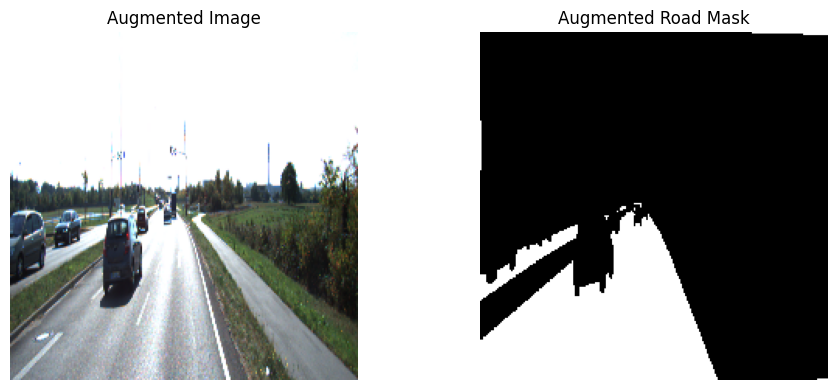

In [34]:
# augmentation 이후 이미지 마스크 정렬 확인해보기
image, mask = train_dataset[0]

image_vis = (
    image
    .permute(1, 2, 0)
    .numpy()
)

mask_vis = (
    mask
    .squeeze(0)
    .numpy()
)

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(image_vis)
plt.title("Augmented Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(
    mask_vis,
    cmap="gray"
)
plt.title("Augmented Road Mask")
plt.axis("off")

plt.tight_layout()
plt.show()

#### 위의 단계에서는 이미지가 augmentation 되더라도 mask도 동일하게 도로 위치를 따라가고 있는지 알아야함.

*aug에 따른 마스크 변경 잘 된 것 같긴 한데 애초에 `맨 갓길 도로`는 마스크 안 돼있었나보다 내 눈엔 `땡이다`*

In [50]:
# DataLoader 생성
from torch.utils.data import DataLoader

BATCH_SIZE = 4


train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=True,
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=True,
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=True,
)

In [36]:
# 실제 batch 확인
images, masks = next(
    iter(train_loader)
)

print(
    "Batch image shape:",
    images.shape
)

print(
    "Batch mask shape :",
    masks.shape
)

print(
    "Image dtype:",
    images.dtype
)

print(
    "Mask dtype:",
    masks.dtype
)

Batch image shape: torch.Size([4, 3, 224, 224])
Batch mask shape : torch.Size([4, 1, 224, 224])
Image dtype: torch.float32
Mask dtype: torch.float32


### 지금까지 확인된 것...
- 원본 이미지 shape: (375, 1242, 3)
- 원본 semantic mask shape: (375, 1242)
- road class 7 존재
- road 비율 약 24.9%
- augmentation 후에도 mask가 0/1 binary로 유지
- Dataset sample: [3,224,224] / [1,224,224]
- Batch: [4,3,224,224] / [4,1,224,224]

## U-Net의 DoubleConv 이해와 구현

In [37]:
# 해상도는 유지하면서 feature를 학습하는 모습을 확인해보아요
import torch
import torch.nn as nn


class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()

        self.block = nn.Sequential(
            nn.Conv2d(
                in_channels,
                out_channels,
                kernel_size=3,
                padding=1,
            ),
            nn.ReLU(inplace=True),

            nn.Conv2d(
                out_channels,
                out_channels,
                kernel_size=3,
                padding=1,
            ),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.block(x)

In [38]:
# U-Net baseline 구현
class UNet(nn.Module):
    def __init__(
        self,
        in_channels=3,
        out_channels=1,
    ):
        super().__init__()

        self.pool = nn.MaxPool2d(
            kernel_size=2,
            stride=2,
        )

        # Encoder
        self.enc1 = DoubleConv(
            in_channels,
            64,
        )
        self.enc2 = DoubleConv(
            64,
            128,
        )
        self.enc3 = DoubleConv(
            128,
            256,
        )
        self.enc4 = DoubleConv(
            256,
            512,
        )

        # Bottleneck
        self.bottleneck = DoubleConv(
            512,
            1024,
        )

        # Decoder
        self.up4 = nn.ConvTranspose2d(
            1024,
            512,
            kernel_size=2,
            stride=2,
        )
        self.dec4 = DoubleConv(
            1024,
            512,
        )

        self.up3 = nn.ConvTranspose2d(
            512,
            256,
            kernel_size=2,
            stride=2,
        )
        self.dec3 = DoubleConv(
            512,
            256,
        )

        self.up2 = nn.ConvTranspose2d(
            256,
            128,
            kernel_size=2,
            stride=2,
        )
        self.dec2 = DoubleConv(
            256,
            128,
        )

        self.up1 = nn.ConvTranspose2d(
            128,
            64,
            kernel_size=2,
            stride=2,
        )
        self.dec1 = DoubleConv(
            128,
            64,
        )

        # Pixel-wise binary output
        self.final = nn.Conv2d(
            64,
            out_channels,
            kernel_size=1,
        )

    def forward(self, x):

        # Encoder
        x1 = self.enc1(x)

        x2 = self.enc2(
            self.pool(x1)
        )

        x3 = self.enc3(
            self.pool(x2)
        )

        x4 = self.enc4(
            self.pool(x3)
        )

        # Bottleneck
        x5 = self.bottleneck(
            self.pool(x4)
        )

        # Decoder
        d4 = self.up4(x5)
        d4 = torch.cat(
            [d4, x4],
            dim=1,
        )
        d4 = self.dec4(d4)

        d3 = self.up3(d4)
        d3 = torch.cat(
            [d3, x3],
            dim=1,
        )
        d3 = self.dec3(d3)

        d2 = self.up2(d3)
        d2 = torch.cat(
            [d2, x2],
            dim=1,
        )
        d2 = self.dec2(d2)

        d1 = self.up1(d2)
        d1 = torch.cat(
            [d1, x1],
            dim=1,
        )
        d1 = self.dec1(d1)

        # sigmoid 하지 않음
        logits = self.final(d1)

        return logits

#### 즉, 앞선 작업은 각 픽셀마다 road 여부를 위한 logit 하나씩 생기는 것입니다.


```
[B,64,224,224]
       ↓
1×1 Conv
       ↓
[B,1,224,224]
```



In [39]:
# shape 체크
unet = UNet().to(device)

dummy_input = torch.randn(
    2,
    3,
    IMAGE_SIZE,
    IMAGE_SIZE,
    device=device,
)

with torch.no_grad():
    dummy_output = unet(dummy_input)

print(
    "Dummy input :",
    dummy_input.shape
)

print(
    "Dummy output:",
    dummy_output.shape
)

Dummy input : torch.Size([2, 3, 224, 224])
Dummy output: torch.Size([2, 1, 224, 224])


순전파는 정상

아래는 내부 구조 확인해보기. 정말로


```
해상도 ↓
채널 ↑
      ↓
bottleneck
      ↓
해상도 ↑
채널 ↓
```
이런 흐름으로 구성될까?


In [40]:
def print_unet_shapes(model, x):

    with torch.no_grad():

        x1 = model.enc1(x)
        print("x1:", x1.shape)

        x2 = model.enc2(
            model.pool(x1)
        )
        print("x2:", x2.shape)

        x3 = model.enc3(
            model.pool(x2)
        )
        print("x3:", x3.shape)

        x4 = model.enc4(
            model.pool(x3)
        )
        print("x4:", x4.shape)

        x5 = model.bottleneck(
            model.pool(x4)
        )
        print("x5:", x5.shape)

        d4 = model.up4(x5)
        print("up4:", d4.shape)

        d4_cat = torch.cat(
            [d4, x4],
            dim=1,
        )
        print(
            "cat4:",
            d4_cat.shape
        )

        d4 = model.dec4(d4_cat)
        print("d4:", d4.shape)

        d3 = model.up3(d4)
        print("up3:", d3.shape)

        d3_cat = torch.cat(
            [d3, x3],
            dim=1,
        )
        print(
            "cat3:",
            d3_cat.shape
        )

        d3 = model.dec3(d3_cat)
        print("d3:", d3.shape)

        d2 = model.up2(d3)
        print("up2:", d2.shape)

        d2_cat = torch.cat(
            [d2, x2],
            dim=1,
        )
        print(
            "cat2:",
            d2_cat.shape
        )

        d2 = model.dec2(d2_cat)
        print("d2:", d2.shape)

        d1 = model.up1(d2)
        print("up1:", d1.shape)

        d1_cat = torch.cat(
            [d1, x1],
            dim=1,
        )
        print(
            "cat1:",
            d1_cat.shape
        )

        d1 = model.dec1(d1_cat)
        print("d1:", d1.shape)

        out = model.final(d1)
        print("out:", out.shape)

In [41]:
sample_batch, _ = next(
    iter(train_loader)
)

sample_batch = sample_batch.to(device)

print_unet_shapes(
    unet,
    sample_batch[:1]
)

x1: torch.Size([1, 64, 224, 224])
x2: torch.Size([1, 128, 112, 112])
x3: torch.Size([1, 256, 56, 56])
x4: torch.Size([1, 512, 28, 28])
x5: torch.Size([1, 1024, 14, 14])
up4: torch.Size([1, 512, 28, 28])
cat4: torch.Size([1, 1024, 28, 28])
d4: torch.Size([1, 512, 28, 28])
up3: torch.Size([1, 256, 56, 56])
cat3: torch.Size([1, 512, 56, 56])
d3: torch.Size([1, 256, 56, 56])
up2: torch.Size([1, 128, 112, 112])
cat2: torch.Size([1, 256, 112, 112])
d2: torch.Size([1, 128, 112, 112])
up1: torch.Size([1, 64, 224, 224])
cat1: torch.Size([1, 128, 224, 224])
d1: torch.Size([1, 64, 224, 224])
out: torch.Size([1, 1, 224, 224])


### Optimizer 구성

In [42]:
LEARNING_RATE = 1e-4

optimizer = torch.optim.Adam(
    unet.parameters(),
    lr=LEARNING_RATE,
)

In [43]:
# 1batch만 학습 테스트
unet.train()

images, masks = next(
    iter(train_loader)
)

images = images.to(
    device,
    non_blocking=True,
)

masks = masks.to(
    device,
    non_blocking=True,
)

optimizer.zero_grad(
    set_to_none=True
)

logits = unet(images)

loss = criterion(
    logits,
    masks
)

loss.backward()

optimizer.step()

print(
    "Images:",
    images.shape
)

print(
    "Masks :",
    masks.shape
)

print(
    "Logits:",
    logits.shape
)

print(
    "Loss:",
    loss.item()
)

Images: torch.Size([4, 3, 224, 224])
Masks : torch.Size([4, 1, 224, 224])
Logits: torch.Size([4, 1, 224, 224])
Loss: 0.6773827075958252


In [44]:
# 학습 전 예측값 확인해보기
with torch.no_grad():

    probs = torch.sigmoid(
        logits
    )

    preds = (
        probs >= 0.5
    ).float()

print(
    "Logit min/max:",
    logits.min().item(),
    logits.max().item()
)

print(
    "Probability min/max:",
    probs.min().item(),
    probs.max().item()
)

print(
    "Prediction unique:",
    torch.unique(preds)
)

Logit min/max: 0.09252530336380005 0.11046908795833588
Probability min/max: 0.5231148600578308 0.5275892019271851
Prediction unique: tensor([1.], device='cuda:0')


In [45]:
# 학습용 공통 함수
from tqdm.auto import tqdm


def run_epoch(
    model,
    loader,
    criterion,
    optimizer=None,
):

    is_train = (
        optimizer is not None
    )

    if is_train:
        model.train()
    else:
        model.eval()

    total_loss = 0.0
    total_iou = 0.0
    total_samples = 0

    iterator = tqdm(
        loader,
        leave=False,
    )

    for images, masks in iterator:

        images = images.to(
            device,
            non_blocking=True,
        )

        masks = masks.to(
            device,
            non_blocking=True,
        )

        batch_size = images.size(0)

        if is_train:

            optimizer.zero_grad(
                set_to_none=True
            )

            logits = model(images)

            loss = criterion(
                logits,
                masks,
            )

            loss.backward()

            optimizer.step()

        else:

            with torch.no_grad():

                logits = model(images)

                loss = criterion(
                    logits,
                    masks,
                )

        iou = binary_iou_from_logits(
            logits,
            masks,
        )

        total_loss += (
            loss.item()
            * batch_size
        )

        total_iou += (
            iou.item()
            * batch_size
        )

        total_samples += batch_size

        iterator.set_postfix(
            loss=f"{loss.item():.4f}",
            iou=f"{iou.item():.4f}",
        )

    return {
        "loss": (
            total_loss
            / total_samples
        ),

        "iou": (
            total_iou
            / total_samples
        ),
    }

## 본격 학습과 Best Checkpoint!

In [51]:
import pandas as pd


def train_model(
    model,
    model_name,
    train_loader,
    val_loader,
    epochs=50,
    lr=1e-4,
):

    model = model.to(device)

    criterion = BCEDiceLoss()

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=lr,
    )

    best_val_iou = -1.0

    history = []

    checkpoint_path = (
        MODEL_DIR
        / f"{model_name}_best.pth"
    )

    for epoch in range(
        1,
        epochs + 1,
    ):

        train_metrics = run_epoch(
            model,
            train_loader,
            criterion,
            optimizer=optimizer,
        )

        val_metrics = run_epoch(
            model,
            val_loader,
            criterion,
            optimizer=None,
        )

        row = {
            "epoch": epoch,

            "train_loss":
                train_metrics["loss"],

            "train_iou":
                train_metrics["iou"],

            "val_loss":
                val_metrics["loss"],

            "val_iou":
                val_metrics["iou"],
        }

        history.append(row)

        print(
            f"[{model_name}] "
            f"Epoch {epoch:03d} | "
            f"train loss="
            f"{row['train_loss']:.4f} | "
            f"train IoU="
            f"{row['train_iou']:.4f} | "
            f"val loss="
            f"{row['val_loss']:.4f} | "
            f"val IoU="
            f"{row['val_iou']:.4f}"
        )

        if (
            row["val_iou"]
            > best_val_iou
        ):

            best_val_iou = (
                row["val_iou"]
            )

            torch.save(
                model.state_dict(),
                checkpoint_path,
            )

            print(
                "  ↳ best checkpoint saved"
            )

    history_df = pd.DataFrame(
        history
    )

    history_path = (
        METRIC_DIR
        / f"{model_name}_history.csv"
    )

    history_df.to_csv(
        history_path,
        index=False,
    )

    print()
    print(
        "Best validation IoU:",
        best_val_iou
    )

    print(
        "Checkpoint:",
        checkpoint_path
    )

    return history_df

In [47]:
# 30 epoch 부터 확인해서 커브 보고 50으로 가고자 함
EPOCHS = 30

unet = UNet().to(device)

unet_history = train_model(
    model=unet,
    model_name="unet",
    train_loader=train_loader,
    val_loader=val_loader,
    epochs=EPOCHS,
    lr=1e-4,
)

  0%|          | 0/40 [00:00<?, ?it/s]

  0%|          | 0/5 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7f80d4146520>
Traceback (most recent call last):
Exception ignored in:   File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
<function _MultiProcessingDataLoaderIter.__del__ at 0x7f80d4146520>    
self._shutdown_workers()
Traceback (most recent call last):
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
        if w.is_alive():
self._shutdown_workers()  File "/usr/lib/python3.13/multiprocessing/process.py", line 160, in is_alive

      File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
assert self._parent_pid == os.getpid(), 'can only test a child process'    
if w.is_alive():AssertionError: 
can only test a child process  File "/usr/lib/p

[unet] Epoch 001 | train loss=0.6769 | train IoU=0.1171 | val loss=0.5390 | val IoU=0.0001
  ↳ best checkpoint saved


  0%|          | 0/40 [00:00<?, ?it/s]

...

[unet] Epoch 029 | train loss=0.2245 | train IoU=0.6995 | val loss=0.2369 | val IoU=0.7055


  0%|          | 0/40 [00:00<?, ?it/s]

  0%|          | 0/5 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7f80d4146520>
Traceback (most recent call last):
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
    if w.is_alive():
  File "/usr/lib/python3.13/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7f80d4146520>Exception ignored in: 
Traceback (most recent call last):
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
<function _MultiProcessingDataLoaderIter.__del__ at 0x7f80d4146520>    self._shutdown_workers()

Traceback (most recent call last):
  File "/usr/local/lib/pyt

[unet] Epoch 030 | train loss=0.1994 | train IoU=0.7456 | val loss=0.2432 | val IoU=0.7364

Best validation IoU: 0.7367185950279236
Checkpoint: /content/drive/MyDrive/Colab Notebooks/2026.789_AI researcher/models/segmentation/unet_best.pth


In [48]:
# Loss와 IoU curve 저장
import matplotlib.pyplot as plt


def plot_history(
    history_df,
    model_name,
):

    # Loss
    plt.figure(figsize=(8, 5))

    plt.plot(
        history_df["epoch"],
        history_df["train_loss"],
        label="Train Loss",
    )

    plt.plot(
        history_df["epoch"],
        history_df["val_loss"],
        label="Validation Loss",
    )

    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(
        f"{model_name} Loss Curve"
    )

    plt.legend()
    plt.grid(alpha=0.3)

    loss_path = (
        FIGURE_DIR
        / f"{model_name}_loss_curve.png"
    )

    plt.savefig(
        loss_path,
        dpi=150,
        bbox_inches="tight",
    )

    plt.show()

    # IoU
    plt.figure(figsize=(8, 5))

    plt.plot(
        history_df["epoch"],
        history_df["train_iou"],
        label="Train IoU",
    )

    plt.plot(
        history_df["epoch"],
        history_df["val_iou"],
        label="Validation IoU",
    )

    plt.xlabel("Epoch")
    plt.ylabel("IoU")
    plt.title(
        f"{model_name} IoU Curve"
    )

    plt.legend()
    plt.grid(alpha=0.3)

    iou_path = (
        FIGURE_DIR
        / f"{model_name}_iou_curve.png"
    )

    plt.savefig(
        iou_path,
        dpi=150,
        bbox_inches="tight",
    )

    plt.show()

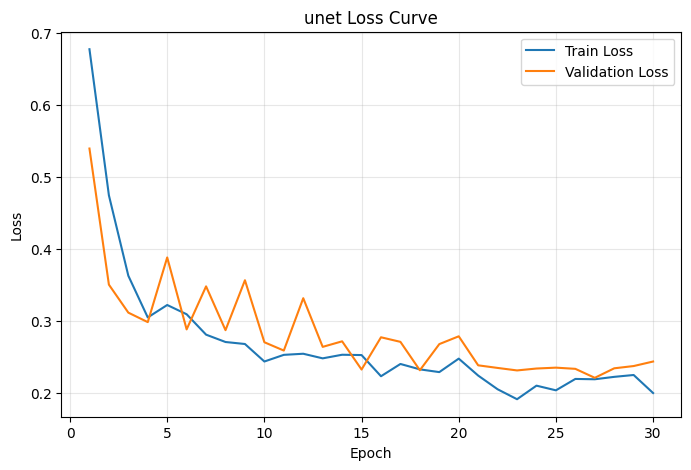

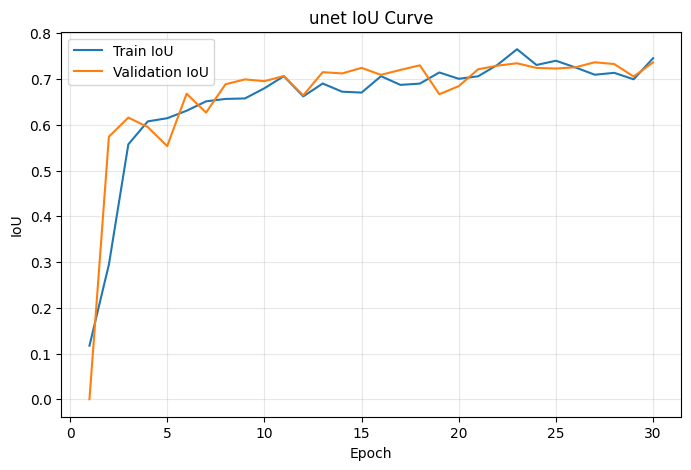

In [49]:
plot_history(
    unet_history,
    "unet",
)

In [52]:
UNET_CHECKPOINT = MODEL_DIR / "unet_best.pth"

unet_best = UNet().to(device)

state_dict = torch.load(
    UNET_CHECKPOINT,
    map_location=device,
    weights_only=True,
)

unet_best.load_state_dict(state_dict)
unet_best.eval()

test_metrics = run_epoch(
    model=unet_best,
    loader=test_loader,
    criterion=BCEDiceLoss(),
    optimizer=None,
)

print("=== U-Net Best Checkpoint Test ===")
print(f"Test Loss: {test_metrics['loss']:.4f}")
print(f"Test IoU : {test_metrics['iou']:.4f}")

  0%|          | 0/5 [00:00<?, ?it/s]

=== U-Net Best Checkpoint Test ===
Test Loss: 0.1307
Test IoU : 0.8132


In [53]:
import pandas as pd

unet_baseline_result = pd.DataFrame([
    {
        "model": "U-Net",
        "best_val_iou": 0.7367185950279236,
        "test_loss": test_metrics["loss"],
        "test_iou": test_metrics["iou"],
        "epochs": 30,
        "batch_size": BATCH_SIZE,
        "learning_rate": 1e-4,
        "image_size": IMAGE_SIZE,
    }
])

display(unet_baseline_result)

unet_baseline_result.to_csv(
    METRIC_DIR / "unet_baseline_result.csv",
    index=False,
)

,model,best_val_iou,test_loss,test_iou,epochs,batch_size,learning_rate,image_size
0,U-Net,0.736719,0.130687,0.81321,30,4,0.0001,224


### 👀U-Net Baseline 학습 결과

U-Net을 30 epoch 학습한 결과 validation IoU는 초반에 빠르게 상승하였고,
약 15 epoch 이후 0.70 이상에서 안정화되는 경향을 보였다.

최고 Validation IoU는 약 0.7367로 `27 epoch`에서 등장했다!

Train과 Validation IoU 간 큰 격차는 관찰되지 않았으며,
30 epoch 시점에서도 Validation IoU가 약 0.736 수준을 유지하여
뚜렷한 과적합은 관찰되지 않았다.

Train 데이터에는 random crop과 horizontal flip augmentation을 적용하고
Validation 데이터에는 resize만 적용하였기 때문에,
일부 epoch에서는 Validation IoU가 Train IoU보다 높게 나타날 수 있다.

최종 모델 비교에서는 마지막 epoch 모델이 아니라
`Validation IoU가 가장 높았던 best checkpoint를 사용`한다.

- Best Validation IoU: 0.7367
- Test Loss: 0.1307
- Test IoU: 0.8132

이 값을 이후 U-Net++ 성능 비교의 baseline으로 사용한다.

## 이제 명확해지는 실험 목표 내지 질문:



> 여러 단계에서 정제된 encoder-decoder feature를 함께 사용함으로써 도로의 영역과 경계를 더 잘 복원하여 IoU가 올라가는가?



**U-Net**


```
U-Net

Encoder feature
       │
       └──────────────→ Decoder
          단일 Skip
```
**U-Net 투뿔**


```
U-Net++

Encoder feature
   │
   ├→ X0,1
   │    ├→ X0,2
   │    │    ├→ X0,3
   │    │    │    └→ X0,4
   │
Nested / Dense Skip Pathway
```


당연히 나머지는 고정합니다.


```
Dataset       동일
Split         동일
Image size    224×224
Batch size    4
Loss          BCE + Dice
Optimizer     Adam
LR            1e-4
Epoch         30
Metric        IoU
Threshold     0.5
Best 기준     Validation IoU
Test set      동일 20장
```



## U-Net ++ 시작해보기.

유넷투뿔은 스킵커넥션 사이에 중간 피처노드를 계속 만들어서 점진적으로 정보를 섞습니다.
이런 모습이죠:


```
X0,0 ── X0,1 ── X0,2 ── X0,3 ── X0,4
  ↓       ↑       ↑       ↑       ↑
X1,0 ── X1,1 ── X1,2 ── X1,3
  ↓       ↑       ↑       ↑
X2,0 ── X2,1 ── X2,2
  ↓       ↑       ↑
X3,0 ── X3,1
  ↓       ↑
X4,0
```

의미는...


```
X0,0
→ 가장 얕은 encoder feature

X1,0
→ 한 번 downsampling된 encoder feature

X0,1
→ X0,0 + upsample(X1,0)을 합쳐 만든 feature

X0,2
→ X0,0 + X0,1 + upsample(X1,1)
```


> 즉 j가 커질수록 같은 해상도에서 더 많은 이전 feature를 모아서 정제한다.




In [54]:
# U-Net ++ 구현
class UNetPlusPlus(nn.Module):
    def __init__(
        self,
        in_channels=3,
        out_channels=1,
    ):
        super().__init__()

        filters = [
            64,
            128,
            256,
            512,
            1024,
        ]

        self.pool = nn.MaxPool2d(
            kernel_size=2,
            stride=2,
        )

        # ---------------------------------
        # Encoder: X(i, 0)
        # ---------------------------------

        self.conv0_0 = DoubleConv(
            in_channels,
            filters[0],
        )

        self.conv1_0 = DoubleConv(
            filters[0],
            filters[1],
        )

        self.conv2_0 = DoubleConv(
            filters[1],
            filters[2],
        )

        self.conv3_0 = DoubleConv(
            filters[2],
            filters[3],
        )

        self.conv4_0 = DoubleConv(
            filters[3],
            filters[4],
        )

        # ---------------------------------
        # j = 1
        # ---------------------------------

        self.up1_0 = nn.ConvTranspose2d(
            filters[1],
            filters[0],
            kernel_size=2,
            stride=2,
        )

        self.conv0_1 = DoubleConv(
            filters[0] * 2,
            filters[0],
        )

        self.up2_0 = nn.ConvTranspose2d(
            filters[2],
            filters[1],
            kernel_size=2,
            stride=2,
        )

        self.conv1_1 = DoubleConv(
            filters[1] * 2,
            filters[1],
        )

        self.up3_0 = nn.ConvTranspose2d(
            filters[3],
            filters[2],
            kernel_size=2,
            stride=2,
        )

        self.conv2_1 = DoubleConv(
            filters[2] * 2,
            filters[2],
        )

        self.up4_0 = nn.ConvTranspose2d(
            filters[4],
            filters[3],
            kernel_size=2,
            stride=2,
        )

        self.conv3_1 = DoubleConv(
            filters[3] * 2,
            filters[3],
        )

        # ---------------------------------
        # j = 2
        # ---------------------------------

        self.up1_1 = nn.ConvTranspose2d(
            filters[1],
            filters[0],
            kernel_size=2,
            stride=2,
        )

        self.conv0_2 = DoubleConv(
            filters[0] * 3,
            filters[0],
        )

        self.up2_1 = nn.ConvTranspose2d(
            filters[2],
            filters[1],
            kernel_size=2,
            stride=2,
        )

        self.conv1_2 = DoubleConv(
            filters[1] * 3,
            filters[1],
        )

        self.up3_1 = nn.ConvTranspose2d(
            filters[3],
            filters[2],
            kernel_size=2,
            stride=2,
        )

        self.conv2_2 = DoubleConv(
            filters[2] * 3,
            filters[2],
        )

        # ---------------------------------
        # j = 3
        # ---------------------------------

        self.up1_2 = nn.ConvTranspose2d(
            filters[1],
            filters[0],
            kernel_size=2,
            stride=2,
        )

        self.conv0_3 = DoubleConv(
            filters[0] * 4,
            filters[0],
        )

        self.up2_2 = nn.ConvTranspose2d(
            filters[2],
            filters[1],
            kernel_size=2,
            stride=2,
        )

        self.conv1_3 = DoubleConv(
            filters[1] * 4,
            filters[1],
        )

        # ---------------------------------
        # j = 4
        # ---------------------------------

        self.up1_3 = nn.ConvTranspose2d(
            filters[1],
            filters[0],
            kernel_size=2,
            stride=2,
        )

        self.conv0_4 = DoubleConv(
            filters[0] * 5,
            filters[0],
        )

        # ---------------------------------
        # Final pixel-wise output
        # ---------------------------------

        self.final = nn.Conv2d(
            filters[0],
            out_channels,
            kernel_size=1,
        )

    def forward(self, x):

        # =================================
        # Encoder column: j = 0
        # =================================

        x0_0 = self.conv0_0(x)

        x1_0 = self.conv1_0(
            self.pool(x0_0)
        )

        x2_0 = self.conv2_0(
            self.pool(x1_0)
        )

        x3_0 = self.conv3_0(
            self.pool(x2_0)
        )

        x4_0 = self.conv4_0(
            self.pool(x3_0)
        )

        # =================================
        # j = 1
        # =================================

        x0_1 = self.conv0_1(
            torch.cat(
                [
                    x0_0,
                    self.up1_0(x1_0),
                ],
                dim=1,
            )
        )

        x1_1 = self.conv1_1(
            torch.cat(
                [
                    x1_0,
                    self.up2_0(x2_0),
                ],
                dim=1,
            )
        )

        x2_1 = self.conv2_1(
            torch.cat(
                [
                    x2_0,
                    self.up3_0(x3_0),
                ],
                dim=1,
            )
        )

        x3_1 = self.conv3_1(
            torch.cat(
                [
                    x3_0,
                    self.up4_0(x4_0),
                ],
                dim=1,
            )
        )

        # =================================
        # j = 2
        # =================================

        x0_2 = self.conv0_2(
            torch.cat(
                [
                    x0_0,
                    x0_1,
                    self.up1_1(x1_1),
                ],
                dim=1,
            )
        )

        x1_2 = self.conv1_2(
            torch.cat(
                [
                    x1_0,
                    x1_1,
                    self.up2_1(x2_1),
                ],
                dim=1,
            )
        )

        x2_2 = self.conv2_2(
            torch.cat(
                [
                    x2_0,
                    x2_1,
                    self.up3_1(x3_1),
                ],
                dim=1,
            )
        )

        # =================================
        # j = 3
        # =================================

        x0_3 = self.conv0_3(
            torch.cat(
                [
                    x0_0,
                    x0_1,
                    x0_2,
                    self.up1_2(x1_2),
                ],
                dim=1,
            )
        )

        x1_3 = self.conv1_3(
            torch.cat(
                [
                    x1_0,
                    x1_1,
                    x1_2,
                    self.up2_2(x2_2),
                ],
                dim=1,
            )
        )

        # =================================
        # j = 4
        # =================================

        x0_4 = self.conv0_4(
            torch.cat(
                [
                    x0_0,
                    x0_1,
                    x0_2,
                    x0_3,
                    self.up1_3(x1_3),
                ],
                dim=1,
            )
        )

        # sigmoid는 하지 않는다.
        # BCEWithLogitsLoss 계열에서 처리.
        return self.final(x0_4)

In [55]:
# 중요한 shape 검증. dummy로 해보기ㅣ
unetpp = UNetPlusPlus().to(device)

dummy_input = torch.randn(
    2,
    3,
    IMAGE_SIZE,
    IMAGE_SIZE,
    device=device,
)

with torch.no_grad():
    dummy_output = unetpp(
        dummy_input
    )

print(
    "Input :",
    dummy_input.shape
)

print(
    "Output:",
    dummy_output.shape
)

Input : torch.Size([2, 3, 224, 224])
Output: torch.Size([2, 1, 224, 224])


In [56]:
# 파라미터 수 비교. 유넷투뿔이 왜 더 무거운지 알 수 있을 예정
def count_parameters(model):
    return sum(
        p.numel()
        for p in model.parameters()
        if p.requires_grad
    )


unet_params = count_parameters(
    UNet()
)

unetpp_params = count_parameters(
    UNetPlusPlus()
)

print(
    f"U-Net parameters    : "
    f"{unet_params:,}"
)

print(
    f"U-Net++ parameters  : "
    f"{unetpp_params:,}"
)

print(
    f"U-Net++ / U-Net     : "
    f"{unetpp_params / unet_params:.2f}x"
)

U-Net parameters    : 31,031,745
U-Net++ parameters  : 36,157,953
U-Net++ / U-Net     : 1.17x




```
더 많은 중간 노드 , 컨캣, 컨브 블록..
```



In [57]:
# 단일 배치 순전, 손실 검증
unetpp = UNetPlusPlus().to(device)

criterion = BCEDiceLoss()

optimizer = torch.optim.Adam(
    unetpp.parameters(),
    lr=1e-4,
)

images, masks = next(
    iter(train_loader)
)

images = images.to(
    device,
    non_blocking=True,
)

masks = masks.to(
    device,
    non_blocking=True,
)

optimizer.zero_grad(
    set_to_none=True
)

logits = unetpp(images)

loss = criterion(
    logits,
    masks
)

loss.backward()

optimizer.step()

print(
    "Images:",
    images.shape
)

print(
    "Masks :",
    masks.shape
)

print(
    "Logits:",
    logits.shape
)

print(
    "Loss  :",
    loss.item()
)

Images: torch.Size([4, 3, 224, 224])
Masks : torch.Size([4, 1, 224, 224])
Logits: torch.Size([4, 1, 224, 224])
Loss  : 0.6670812368392944


In [58]:
if torch.cuda.is_available():

    allocated = (
        torch.cuda.memory_allocated()
        / 1024**3
    )

    reserved = (
        torch.cuda.memory_reserved()
        / 1024**3
    )

    max_allocated = (
        torch.cuda.max_memory_allocated()
        / 1024**3
    )

    print(
        f"Allocated    : "
        f"{allocated:.2f} GB"
    )

    print(
        f"Reserved     : "
        f"{reserved:.2f} GB"
    )

    print(
        f"Max allocated: "
        f"{max_allocated:.2f} GB"
    )

Allocated    : 1.02 GB
Reserved     : 3.50 GB
Max allocated: 2.89 GB


In [59]:
# 유넷투뿔 30epoch해보기
EPOCHS = 30

unetpp = UNetPlusPlus().to(
    device
)

unetpp_history = train_model(
    model=unetpp,
    model_name="unetpp",
    train_loader=train_loader,
    val_loader=val_loader,
    epochs=EPOCHS,
    lr=1e-4,
)

  0%|          | 0/40 [00:00<?, ?it/s]

  0%|          | 0/5 [00:00<?, ?it/s]

[unetpp] Epoch 001 | train loss=0.6786 | train IoU=0.1040 | val loss=0.6325 | val IoU=0.0000
  ↳ best checkpoint saved


  0%|          | 0/40 [00:00<?, ?it/s]

  0%|          | 0/5 [00:00<?, ?it/s]

...

  0%|          | 0/5 [00:00<?, ?it/s]

[unetpp] Epoch 029 | train loss=0.2366 | train IoU=0.6975 | val loss=0.2410 | val IoU=0.7425


  0%|          | 0/40 [00:00<?, ?it/s]

  0%|          | 0/5 [00:00<?, ?it/s]

[unetpp] Epoch 030 | train loss=0.2233 | train IoU=0.7077 | val loss=0.2169 | val IoU=0.7452
  ↳ best checkpoint saved

Best validation IoU: 0.7451908230781555
Checkpoint: /content/drive/MyDrive/Colab Notebooks/2026.789_AI researcher/models/segmentation/unetpp_best.pth


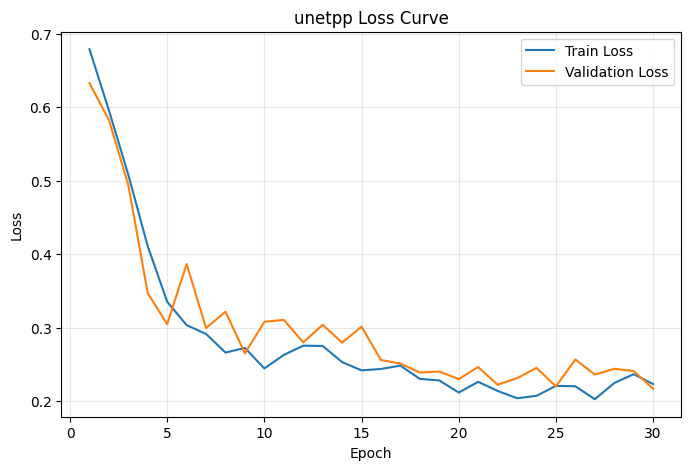

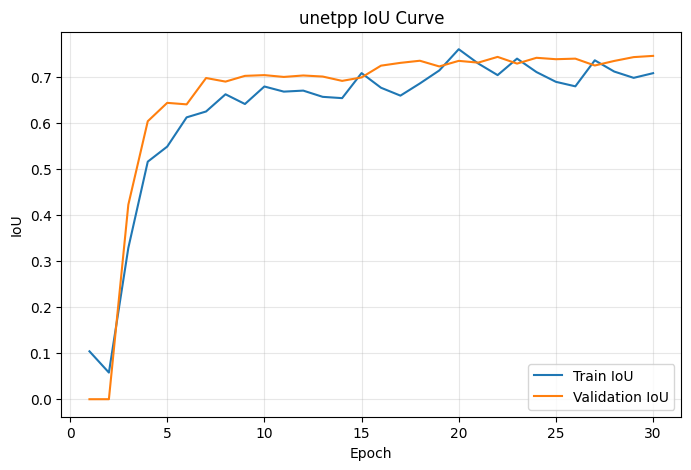

In [60]:
plot_history(
    unetpp_history,
    "unetpp",
)

In [61]:
# Best U-Net++ 테스트
UNETPP_CHECKPOINT = (
    MODEL_DIR
    / "unetpp_best.pth"
)

unetpp_best = (
    UNetPlusPlus()
    .to(device)
)

state_dict = torch.load(
    UNETPP_CHECKPOINT,
    map_location=device,
    weights_only=True,
)

unetpp_best.load_state_dict(
    state_dict
)

unetpp_best.eval()

unetpp_test_metrics = run_epoch(
    model=unetpp_best,
    loader=test_loader,
    criterion=BCEDiceLoss(),
    optimizer=None,
)

print(
    "=== U-Net++ Best Checkpoint Test ==="
)

print(
    f"Test Loss: "
    f"{unetpp_test_metrics['loss']:.4f}"
)

print(
    f"Test IoU : "
    f"{unetpp_test_metrics['iou']:.4f}"
)

  0%|          | 0/5 [00:00<?, ?it/s]

=== U-Net++ Best Checkpoint Test ===
Test Loss: 0.1462
Test IoU : 0.8195


## 두 모델 비교해보기

| Model | Best Val IoU | Test Loss | Test IoU | Params |
|---|---:|---:|---:|---:|
| U-Net | 0.7367 | 0.1307 | 0.8132 | 31,031,745 |
| U-Net++ | 0.7452 | 0.1462 | 0.8195 | 36,157,953 |

In [62]:
# 루브릭용 최종 비교표 저장하기
comparison_df = pd.DataFrame([
    {
        "model": "U-Net",
        "best_val_iou": 0.7367185950279236,
        "test_loss": 0.1307,
        "test_iou": 0.8132,
        "parameters": 31_031_745,
    },
    {
        "model": "U-Net++",
        "best_val_iou": 0.7451908230781555,
        "test_loss": 0.1462,
        "test_iou": 0.8195,
        "parameters": 36_157_953,
    },
])

comparison_df["test_iou_gain_vs_unet"] = (
    comparison_df["test_iou"]
    - comparison_df.loc[
        comparison_df["model"] == "U-Net",
        "test_iou"
    ].iloc[0]
)

display(comparison_df)

comparison_df.to_csv(
    METRIC_DIR / "unet_vs_unetpp_comparison.csv",
    index=False,
)

,model,best_val_iou,test_loss,test_iou,parameters,test_iou_gain_vs_unet
0,U-Net,0.736719,0.1307,0.8132,31031745,0.0000
1,U-Net++,0.745191,0.1462,0.8195,36157953,0.0063


### U-Net vs U-Net++ 정량 비교

동일한 KITTI 데이터 split, 224×224 입력 크기, batch size 4,
Adam optimizer, learning rate 1e-4, BCE+Dice loss, 30 epoch 조건으로
U-Net과 U-Net++를 비교했다.

| Model | Best Val IoU | Test IoU |
|---|---:|---:|
| U-Net | 0.7367 | 0.8132 |
| U-Net++ | 0.7452 | 0.8195 |

U-Net++는 U-Net보다 Validation IoU에서 약 0.0085,
Test IoU에서 약 0.0063 높은 결과가 나왔다.

개선 폭은 크지 않지만 동일한 실험 조건에서 U-Net++가
일관되게 더 높은 IoU를 기록했다.

한편 U-Net++의 학습 파라미터 수는 약 36.16M으로,
U-Net의 약 31.03M보다 약 17% 많았다.

따라서 이번 결과는 소폭의 segmentation 성능 향상과
추가적인 모델 복잡도 사이의 trade-off 관계임을 알 수 있다.

In [63]:
# 샘플 별 IoU 계산
@torch.no_grad()
def sample_iou_from_logits(
    logits,
    targets,
    threshold=0.5,
    smooth=1e-6,
):
    probs = torch.sigmoid(logits)

    preds = (probs >= threshold).float()
    targets = (targets >= 0.5).float()

    preds = preds.view(preds.size(0), -1)
    targets = targets.view(targets.size(0), -1)

    intersection = (preds * targets).sum(dim=1)

    union = (
        preds.sum(dim=1)
        + targets.sum(dim=1)
        - intersection
    )

    iou = (
        intersection + smooth
    ) / (
        union + smooth
    )

    return iou

In [64]:
# Test 전체에서 U-Net과 U-Net ++ 예측 수집정리
@torch.no_grad()
def collect_test_predictions(
    unet_model,
    unetpp_model,
    loader,
):
    unet_model.eval()
    unetpp_model.eval()

    results = []

    sample_index = 0

    for images, masks in loader:

        images = images.to(
            device,
            non_blocking=True,
        )

        masks = masks.to(
            device,
            non_blocking=True,
        )

        unet_logits = unet_model(images)
        unetpp_logits = unetpp_model(images)

        unet_ious = sample_iou_from_logits(
            unet_logits,
            masks,
        )

        unetpp_ious = sample_iou_from_logits(
            unetpp_logits,
            masks,
        )

        unet_preds = (
            torch.sigmoid(unet_logits)
            >= 0.5
        ).float()

        unetpp_preds = (
            torch.sigmoid(unetpp_logits)
            >= 0.5
        ).float()

        for i in range(images.size(0)):

            results.append({
                "index": sample_index,

                "image":
                    images[i]
                    .detach()
                    .cpu(),

                "mask":
                    masks[i]
                    .detach()
                    .cpu(),

                "unet_pred":
                    unet_preds[i]
                    .detach()
                    .cpu(),

                "unetpp_pred":
                    unetpp_preds[i]
                    .detach()
                    .cpu(),

                "unet_iou":
                    float(
                        unet_ious[i]
                        .detach()
                        .cpu()
                    ),

                "unetpp_iou":
                    float(
                        unetpp_ious[i]
                        .detach()
                        .cpu()
                    ),
            })

            sample_index += 1

    return results

In [65]:
test_results = collect_test_predictions(
    unet_best,
    unetpp_best,
    test_loader,
)

print(
    "Collected test samples:",
    len(test_results)
)

Collected test samples: 20


In [66]:
# 샘플별 차이 표로 확인
comparison_samples = pd.DataFrame([
    {
        "index": r["index"],
        "unet_iou": r["unet_iou"],
        "unetpp_iou": r["unetpp_iou"],
        "iou_gain": (
            r["unetpp_iou"]
            - r["unet_iou"]
        ),
    }
    for r in test_results
])

display(
    comparison_samples
    .sort_values(
        "iou_gain",
        ascending=False,
    )
)

,index,unet_iou,unetpp_iou,iou_gain
17,17,0.867110,0.937300,0.070190
0,0,0.865542,0.932327,0.066785
13,13,0.725129,0.791613,0.066484
12,12,0.646472,0.704938,0.058466
10,10,0.890352,0.927901,0.037549
9,9,0.917142,0.949663,0.032520
19,19,0.885878,0.900527,0.014648
3,3,0.618054,0.628955,0.010902
8,8,0.913651,0.923501,0.009850
15,15,0.839946,0.844978,0.005032


In [67]:
sorted_df = comparison_samples.sort_values(
    "iou_gain",
    ascending=False,
)

best_idx = int(
    sorted_df.iloc[0]["index"]
)

worst_idx = int(
    sorted_df.iloc[-1]["index"]
)

similar_idx = int(
    comparison_samples.iloc[
        comparison_samples[
            "iou_gain"
        ].abs().argmin()
    ]["index"]
)

selected_indices = [
    best_idx,
    similar_idx,
    worst_idx,
]

print(
    "Selected indices:",
    selected_indices
)

Selected indices: [17, 11, 4]


In [68]:
def visualize_comparison(
    result,
    save_path=None,
):

    image = (
        result["image"]
        .permute(1, 2, 0)
        .numpy()
    )

    gt = (
        result["mask"]
        .squeeze(0)
        .numpy()
    )

    unet_pred = (
        result["unet_pred"]
        .squeeze(0)
        .numpy()
    )

    unetpp_pred = (
        result["unetpp_pred"]
        .squeeze(0)
        .numpy()
    )

    fig = plt.figure(
        figsize=(16, 4)
    )

    ax1 = fig.add_subplot(
        1, 4, 1
    )
    ax1.imshow(image)
    ax1.set_title("Input")
    ax1.axis("off")

    ax2 = fig.add_subplot(
        1, 4, 2
    )
    ax2.imshow(
        gt,
        cmap="gray",
    )
    ax2.set_title("Ground Truth")
    ax2.axis("off")

    ax3 = fig.add_subplot(
        1, 4, 3
    )
    ax3.imshow(
        unet_pred,
        cmap="gray",
    )
    ax3.set_title(
        f"U-Net\n"
        f"IoU={result['unet_iou']:.4f}"
    )
    ax3.axis("off")

    ax4 = fig.add_subplot(
        1, 4, 4
    )
    ax4.imshow(
        unetpp_pred,
        cmap="gray",
    )
    ax4.set_title(
        f"U-Net++\n"
        f"IoU={result['unetpp_iou']:.4f}"
    )
    ax4.axis("off")

    fig.tight_layout()

    if save_path is not None:
        fig.savefig(
            save_path,
            dpi=150,
            bbox_inches="tight",
        )

    plt.show()


Sample 17 | U-Net=0.8671 | U-Net++=0.9373 | gain=+0.0702


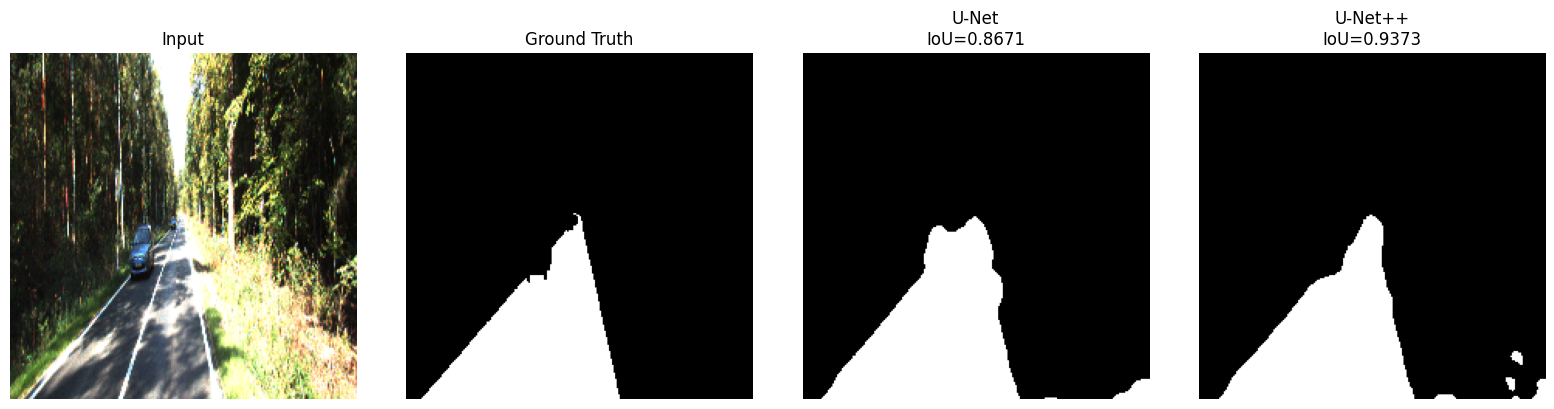


Sample 11 | U-Net=0.8609 | U-Net++=0.8594 | gain=-0.0015


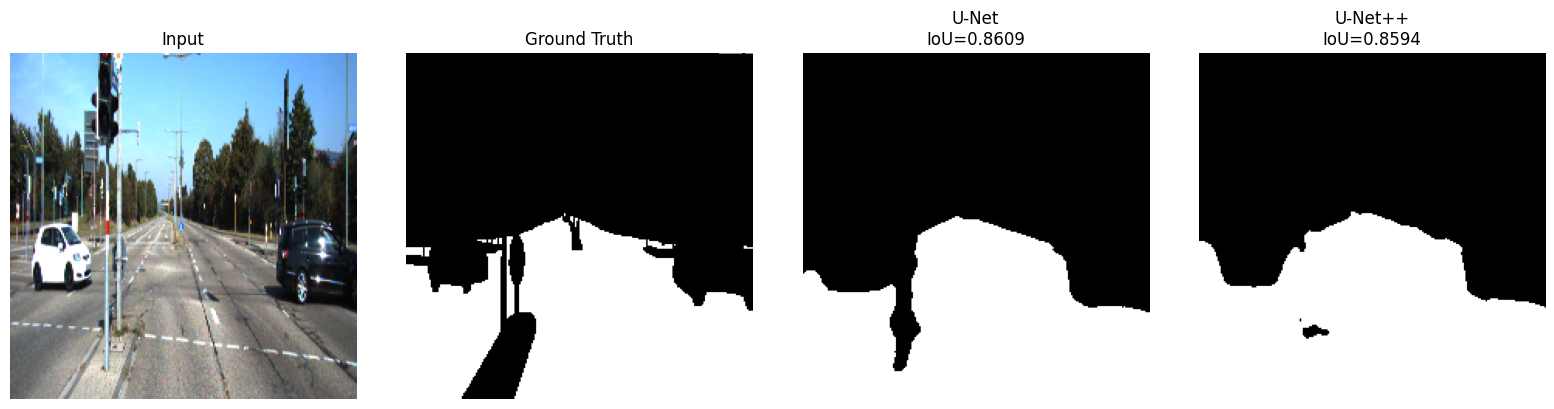


Sample 4 | U-Net=0.9708 | U-Net++=0.8913 | gain=-0.0795


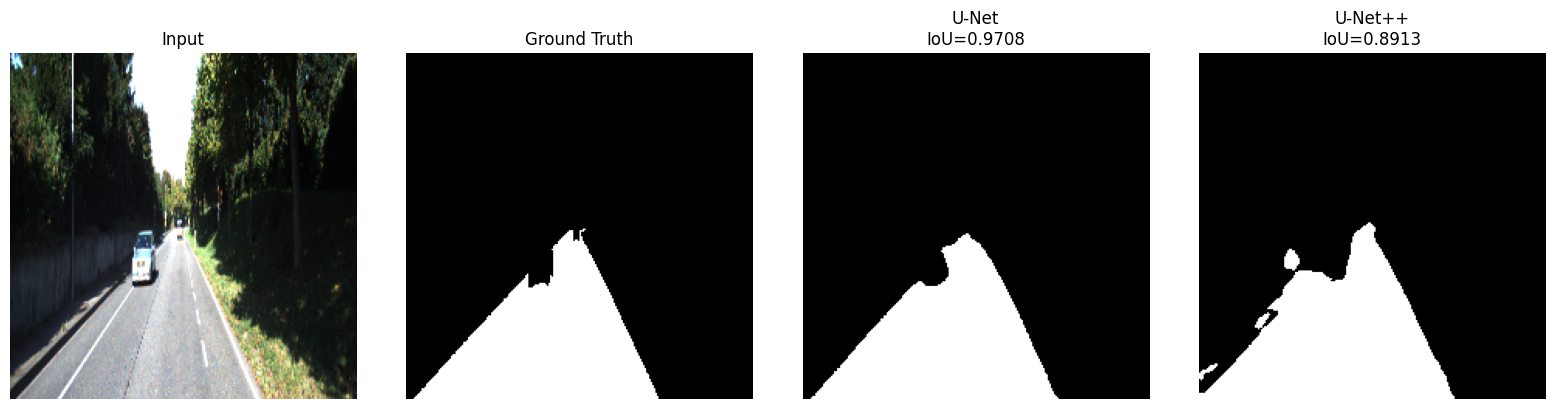

In [69]:
for idx in selected_indices:

    result = test_results[idx]

    gain = (
        result["unetpp_iou"]
        - result["unet_iou"]
    )

    print(
        f"\nSample {idx} | "
        f"U-Net={result['unet_iou']:.4f} | "
        f"U-Net++={result['unetpp_iou']:.4f} | "
        f"gain={gain:+.4f}"
    )

    save_path = (
        FIGURE_DIR
        / f"comparison_sample_{idx:02d}.png"
    )

    visualize_comparison(
        result,
        save_path=save_path,
    )

In [70]:
# 전체 20장 샘플별 IoU 저장
comparison_samples.to_csv(
    METRIC_DIR
    / "test_sample_iou_comparison.csv",
    index=False,
)

display(
    comparison_samples.describe()
)

,index,unet_iou,unetpp_iou,iou_gain
count,20.00000,20.000000,20.000000,20.000000
mean,9.50000,0.813210,0.819468,0.006258
std,5.91608,0.147856,0.157361,0.041473
min,0.00000,0.339261,0.297910,-0.079484
25%,4.75000,0.777603,0.780600,-0.009006
50%,9.50000,0.866326,0.885189,0.003629
75%,14.25000,0.893674,0.914786,0.033777
max,19.00000,0.970751,0.949663,0.070190


## 정성적 평가 결과를 보자면요...

Test 이미지 20장에 대하여...
U-Net ++ 는
- 어떤 장면에서는 꽤 좋아짐
- 어떤 장면에서는 거의 동일
- 어떤 장면에서는 오히려 꽤 나빠짐

그 결과 전체 평균을 내면
U-Net++가 아주 조금 우세

동일한 학습 조건에서 U-Net++는 U-Net보다 Best Validation IoU와 Test Mean IoU 모두 소폭 높은 결과를 기록했다.

Test Mean IoU는 0.8132에서 0.8195로 약 0.0063 증가했다.

`그러나` 20개 test sample을 개별 분석한 결과 U-Net++가 우세한 경우는 11개, U-Net이 우세한 경우는 9개로, 모든 이미지에서 일관된 개선이 나타난 것은 아니었다.

특히 U-Net++는 일부 복잡한 경계에서 GT와의 overlap을 개선했지만 다른 사례에서는 세밀한 경계 반응이 추가적인 false positive로 이어지기도 했다.

따라서 이번 실험에서는 U-Net++의 nested skip connection이 평균적인 segmentation 성능을 소폭 향상시켰지만, 증가한 모델 복잡도에 비해 개선 폭은 제한적이었다고 생각한다.

## Precision, Recall, Dice 계산

- Precision: 모델이 road라고 칠한 픽셀 중 실제 road인 비율 → False Positive에 민감
- Recall: 실제 road 픽셀 중 모델이 road라고 찾아낸 비율 → False Negative에 민감
- Dice: 예측 영역과 GT 영역의 겹침 정도
- IoU: 교집합 / 합집합

In [71]:
# 픽셀단위 메트릭 함수 정의
@torch.no_grad()
def segmentation_metrics_from_logits(
    logits,
    targets,
    threshold=0.5,
    eps=1e-6,
):
    probs = torch.sigmoid(logits)
    preds = (probs >= threshold).float()
    targets = (targets >= 0.5).float()

    preds = preds.view(preds.size(0), -1)
    targets = targets.view(targets.size(0), -1)

    tp = (preds * targets).sum(dim=1)

    fp = (
        preds * (1.0 - targets)
    ).sum(dim=1)

    fn = (
        (1.0 - preds) * targets
    ).sum(dim=1)

    precision = (
        tp + eps
    ) / (
        tp + fp + eps
    )

    recall = (
        tp + eps
    ) / (
        tp + fn + eps
    )

    dice = (
        2.0 * tp + eps
    ) / (
        2.0 * tp + fp + fn + eps
    )

    iou = (
        tp + eps
    ) / (
        tp + fp + fn + eps
    )

    return {
        "precision": precision,
        "recall": recall,
        "dice": dice,
        "iou": iou,
        "tp": tp,
        "fp": fp,
        "fn": fn,
    }

In [72]:
# 모델 하나으 ㅣ테스트 전체 메트릭 수집
@torch.no_grad()
def evaluate_segmentation_metrics(
    model,
    loader,
):
    model.eval()

    rows = []
    sample_index = 0

    for images, masks in loader:

        images = images.to(
            device,
            non_blocking=True,
        )

        masks = masks.to(
            device,
            non_blocking=True,
        )

        logits = model(images)

        metrics = segmentation_metrics_from_logits(
            logits,
            masks,
            threshold=0.5,
        )

        batch_size = images.size(0)

        for i in range(batch_size):

            rows.append({
                "index": sample_index,
                "precision": float(
                    metrics["precision"][i].cpu()
                ),
                "recall": float(
                    metrics["recall"][i].cpu()
                ),
                "dice": float(
                    metrics["dice"][i].cpu()
                ),
                "iou": float(
                    metrics["iou"][i].cpu()
                ),
                "tp": float(
                    metrics["tp"][i].cpu()
                ),
                "fp": float(
                    metrics["fp"][i].cpu()
                ),
                "fn": float(
                    metrics["fn"][i].cpu()
                ),
            })

            sample_index += 1

    return pd.DataFrame(rows)

In [73]:
# 두개 모델 평가를 위한 테스트 샘플 잘 불러오나 확인
unet_metric_df = evaluate_segmentation_metrics(
    unet_best,
    test_loader,
)

unetpp_metric_df = evaluate_segmentation_metrics(
    unetpp_best,
    test_loader,
)

print("U-Net samples   :", len(unet_metric_df))
print("U-Net++ samples :", len(unetpp_metric_df))

U-Net samples   : 20
U-Net++ samples : 20


In [74]:
# 평균 성능 비교표
metric_summary = pd.DataFrame([
    {
        "model": "U-Net",
        "precision": unet_metric_df["precision"].mean(),
        "recall": unet_metric_df["recall"].mean(),
        "dice": unet_metric_df["dice"].mean(),
        "iou": unet_metric_df["iou"].mean(),
    },
    {
        "model": "U-Net++",
        "precision": unetpp_metric_df["precision"].mean(),
        "recall": unetpp_metric_df["recall"].mean(),
        "dice": unetpp_metric_df["dice"].mean(),
        "iou": unetpp_metric_df["iou"].mean(),
    },
])

display(
    metric_summary.round(4)
)

,model,precision,recall,dice,iou
0,U-Net,0.8536,0.9429,0.8886,0.8132
1,U-Net++,0.8471,0.9622,0.8911,0.8195


In [75]:
# 두 모델의 차이 계산
metric_gain = {
    "precision_gain": (
        metric_summary.loc[
            metric_summary["model"] == "U-Net++",
            "precision"
        ].iloc[0]
        -
        metric_summary.loc[
            metric_summary["model"] == "U-Net",
            "precision"
        ].iloc[0]
    ),

    "recall_gain": (
        metric_summary.loc[
            metric_summary["model"] == "U-Net++",
            "recall"
        ].iloc[0]
        -
        metric_summary.loc[
            metric_summary["model"] == "U-Net",
            "recall"
        ].iloc[0]
    ),

    "dice_gain": (
        metric_summary.loc[
            metric_summary["model"] == "U-Net++",
            "dice"
        ].iloc[0]
        -
        metric_summary.loc[
            metric_summary["model"] == "U-Net",
            "dice"
        ].iloc[0]
    ),

    "iou_gain": (
        metric_summary.loc[
            metric_summary["model"] == "U-Net++",
            "iou"
        ].iloc[0]
        -
        metric_summary.loc[
            metric_summary["model"] == "U-Net",
            "iou"
        ].iloc[0]
    ),
}

for key, value in metric_gain.items():
    print(
        f"{key:16s}: {value:+.4f}"
    )

precision_gain  : -0.0066
recall_gain     : +0.0193
dice_gain       : +0.0025
iou_gain        : +0.0063


In [76]:
# 메트릭이 좋아도 정성적으로 뭔가 아니었다 싶었던 U-Net++의 FP/FN

fp_fn_summary = pd.DataFrame([
    {
        "model": "U-Net",
        "mean_fp_pixels": unet_metric_df["fp"].mean(),
        "mean_fn_pixels": unet_metric_df["fn"].mean(),
    },
    {
        "model": "U-Net++",
        "mean_fp_pixels": unetpp_metric_df["fp"].mean(),
        "mean_fn_pixels": unetpp_metric_df["fn"].mean(),
    },
])

display(
    fp_fn_summary.round(1)
)

,model,mean_fp_pixels,mean_fn_pixels
0,U-Net,1647.5,559.2
1,U-Net++,1979.5,342.4




```
U-Net++ FP ↑
→ 도로 아닌 곳까지 더 많이 칠함
→ Precision 악화 가능

U-Net++ FN ↓
→ 실제 도로를 덜 놓침
→ Recall 개선 가능
```



In [77]:
# 샘플별 상세 비교 저장
per_sample_metrics = pd.DataFrame({
    "index": unet_metric_df["index"],

    "unet_precision":
        unet_metric_df["precision"],

    "unetpp_precision":
        unetpp_metric_df["precision"],

    "unet_recall":
        unet_metric_df["recall"],

    "unetpp_recall":
        unetpp_metric_df["recall"],

    "unet_dice":
        unet_metric_df["dice"],

    "unetpp_dice":
        unetpp_metric_df["dice"],

    "unet_iou":
        unet_metric_df["iou"],

    "unetpp_iou":
        unetpp_metric_df["iou"],
})

per_sample_metrics["precision_gain"] = (
    per_sample_metrics["unetpp_precision"]
    - per_sample_metrics["unet_precision"]
)

per_sample_metrics["recall_gain"] = (
    per_sample_metrics["unetpp_recall"]
    - per_sample_metrics["unet_recall"]
)

per_sample_metrics["dice_gain"] = (
    per_sample_metrics["unetpp_dice"]
    - per_sample_metrics["unet_dice"]
)

per_sample_metrics["iou_gain"] = (
    per_sample_metrics["unetpp_iou"]
    - per_sample_metrics["unet_iou"]
)

display(
    per_sample_metrics.round(4)
)

per_sample_metrics.to_csv(
    METRIC_DIR
    / "unet_vs_unetpp_pixel_metrics.csv",
    index=False,
)

metric_summary.to_csv(
    METRIC_DIR
    / "unet_vs_unetpp_metric_summary.csv",
    index=False,
)

,index,unet_precision,unetpp_precision,unet_recall,unetpp_recall,unet_dice,unetpp_dice,unet_iou,unetpp_iou,precision_gain,recall_gain,dice_gain,iou_gain
0,0,0.8868,0.9514,0.9731,0.9789,0.9279,0.9650,0.8655,0.9323,0.0647,0.0058,0.0371,0.0668
1,1,0.9196,0.9012,0.9660,0.9763,0.9422,0.9372,0.8908,0.8819,-0.0183,0.0102,-0.0050,-0.0089
2,2,0.9667,0.9385,0.9515,0.9698,0.9590,0.9539,0.9213,0.9119,-0.0281,0.0183,-0.0051,-0.0094
3,3,0.6677,0.6824,0.8926,0.8893,0.7639,0.7722,0.6181,0.6290,0.0147,-0.0033,0.0083,0.0109
4,4,0.9778,0.8949,0.9926,0.9955,0.9852,0.9425,0.9708,0.8913,-0.0829,0.0028,-0.0427,-0.0795
5,5,0.3489,0.3003,0.9244,0.9735,0.5066,0.4591,0.3393,0.2979,-0.0486,0.0491,-0.0476,-0.0414
6,6,0.9436,0.9262,0.9538,0.9749,0.9487,0.9499,0.9024,0.9046,-0.0175,0.0211,0.0012,0.0022
7,7,0.8654,0.8481,0.9758,0.9892,0.9173,0.9133,0.8472,0.8404,-0.0173,0.0135,-0.0040,-0.0068
8,8,0.9553,0.9433,0.9545,0.9778,0.9549,0.9602,0.9137,0.9235,-0.0120,0.0233,0.0054,0.0099
9,9,0.9379,0.9717,0.9764,0.9767,0.9568,0.9742,0.9171,0.9497,0.0338,0.0003,0.0174,0.0325


### 🗯️추가 픽셀 단위 지표 분석 결과🐾

Test set에 대해 `Precision`, `Recall`, `Dice`를 추가로 비교했다.

| Model | Precision | Recall | Dice | IoU |
|---|---:|---:|---:|---:|
| U-Net | 0.8536 | 0.9429 | 0.8886 | 0.8132 |
| U-Net++ | 0.8471 | 0.9622 | 0.8911 | 0.8195 |

- U-Net++는 U-Net 대비 Recall이 약 0.0193 증가한 반면,
Precision은 약 0.0066 감소했다.

- 평균 False Negative 픽셀은 559.2에서 342.4로 감소했지만,
False Positive 픽셀은 1647.5에서 1979.5로 증가했다.

- 이는 U-Net++가 실제 road 영역을 더 많이 회수하는 경향이 있는 반면,
일부 이미지에서는 주변 영역까지 road로 예측하는 `과잉 분할이 증가`했음을 의미한다.

- 결과적으로 Dice와 IoU는 각각 0.0025, 0.0063 소폭 개선되었지만,
모든 샘플에서 U-Net++가 우세한 것은 아니었다.

- 따라서 이번 실험에서는 U-Net++의 nested skip connection이 평균적인
영역 복원 성능을 소폭 개선했으나, 그 개선은 Recall 증가에 더 크게
기여했고 Precision 측면에서는 일부 trade-off가 나타났다.

| 루브릭 | 실험 여부 | 근거 |
|---|---|---|
| **1. U-Net 세그멘테이션 정상 수행** | 했음 | KITTI 200장 구성, image-mask pair 검증, train/val/test `160/20/20`, augmentation, U-Net 학습, best checkpoint, Test IoU `0.8132`, 시각화까지 완료 |
| **2. U-Net++ 성공적 구현** | 했음 | `DoubleConv`를 재사용하면서 `X0_0 ~ X0_4`의 nested dense skip pathway를 직접 구현했고, shape/backward 검증 후 30 epoch 학습 및 best checkpoint 저장, Test IoU `0.8195`까지 완료 |
| **3. 두 모델 정량·정성 비교** | 했음 | 동일 split·224×224·batch 4·Adam `1e-4`·BCE+Dice·30 epoch 조건으로 비교했고, IoU뿐 아니라 Precision/Recall/Dice와 동일 test sample의 GT/U-Net/U-Net++ 비교 이미지까지 포함 |

## 프로젝트 회고

이번 실험을 통해 모델의 성능은 하나의 숫자만 보는 것이 아니라,
IoU, Precision, Recall, Dice와 실제 예측 이미지를 함께 살펴야 한다는 점을
배웠다.

또한 더 복잡한 모델이 항상 모든 사례에서 우월한 것은 아니며,
성능 향상과 모델 복잡도 사이의 trade-off도 함께 고려해야 함을 알게 되었다.